<a href="https://colab.research.google.com/github/terrydw-hcc/ITAI-1371-ML-Labs/blob/main/L10_TerryWilliams_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 10 Lab - Unsupervised Learning

**Objective:** To understand and apply two common **unsupervised learning** techniques: **K-Means Clustering** for finding groups in data and **Principal Component Analysis (PCA)** for dimensionality reduction.

**In this lab, you will write the code to perform clustering and PCA, and you will interpret the results.**

## Part 1: Supervised vs. Unsupervised Learning

So far, every model we have built has been a **supervised learning** model. This means we had **labeled data**—we had both the features (X) and the correct answer, or target (y). The goal was to learn a mapping from X to y.

In **unsupervised learning**, we only have the features (X). There is **no target variable**. The goal is to discover interesting structures or patterns hidden in the data on its own.

Two major types of unsupervised learning are:
*   **Clustering:** Automatically grouping similar data points together.
*   **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering

**Concept:** K-Means is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:
1.  Randomly placing `k` centroids (the center of a cluster) in the data.
2.  **Assignment Step:** Assigning each data point to its nearest centroid.
3.  **Update Step:** Moving each centroid to the average position of all the points assigned to it.
4.  Repeating steps 2 and 3 until the centroids stop moving.

**Problem:** We will use a synthetic dataset of customer spending habits to segment them into groups.

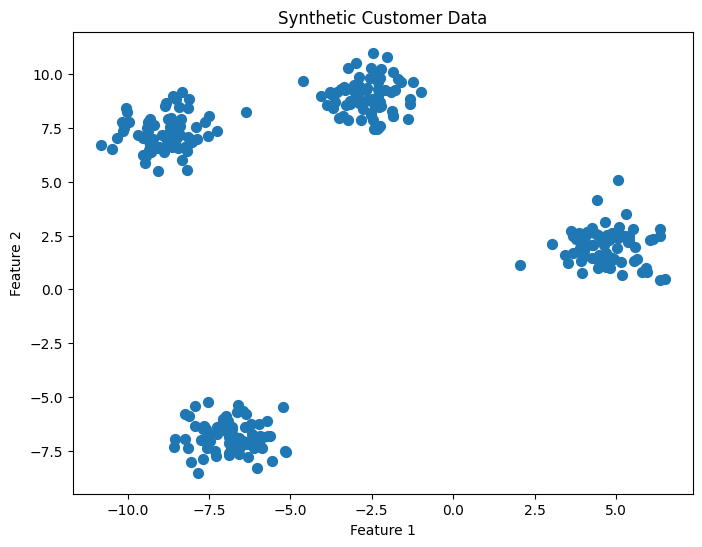

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic customer-like data: 4 natural blobs in 2D feature space.
# We deliberately KNOW the true number of clusters (4) so we can later verify
# that the elbow method and K-Means together rediscover that structure.
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Visualize the raw data BEFORE clustering -- pretend we're seeing it for the first time.
# A human can already see roughly 4 groups, but the algorithm has to discover that on its own.
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)

**Concept:** How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.

**Your Task:** Calculate and plot the inertia for `k` values from 1 to 10.

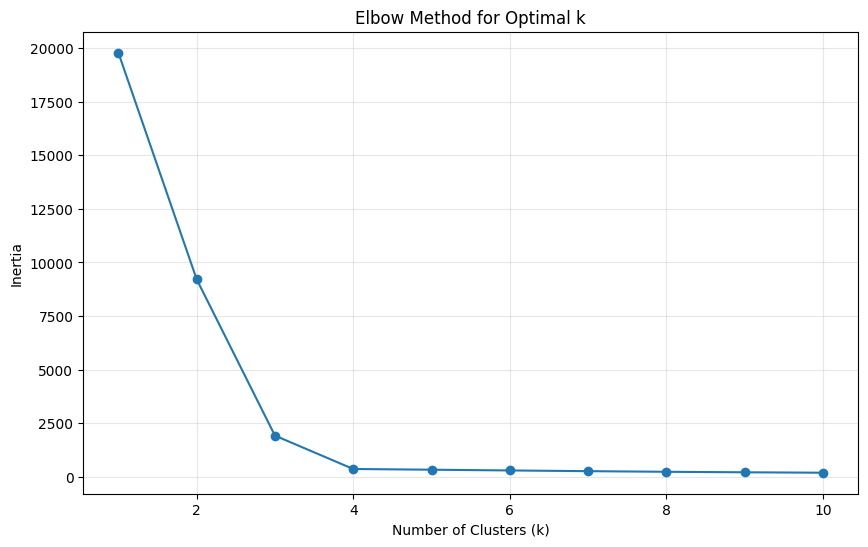

Inertia for each k:
  k= 1:   19780.25
  k= 2:    9211.21
  k= 3:    1919.36
  k= 4:     362.47
  k= 5:     329.27
  k= 6:     294.61
  k= 7:     261.56
  k= 8:     232.01
  k= 9:     209.10
  k=10:     188.72


In [2]:
from sklearn.cluster import KMeans

# 1. Container for the inertia value at each k
inertia = []

# 2. Run K-Means for k = 1..10 and record how tight the resulting clusters are.
# n_init=10 runs the algorithm with 10 different random initializations and keeps the best result.
# This addresses the lecture's "Sensitive to Initialization" limitation (Slide 15) -- without it,
# a bad random starting point could give us a misleading inertia value.
for k in range(1, 11):
    # 3. Fit a fresh K-Means model with the current k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)

    # 4. Save the inertia: sum of squared distances of every point to its assigned centroid.
    # Lower = tighter clusters. By definition, more centroids always means lower inertia,
    # which is why we look for the ELBOW rather than just minimizing.
    inertia.append(kmeans.inertia_)

# 5. Plot inertia vs k -- this is essentially a Scree Plot (Slide 21) for clustering
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.show()

# Print the raw numbers so the elbow is visible numerically too,
# not just visually -- the steepness change is unmistakable.
print("Inertia for each k:")
for k, val in zip(range(1, 11), inertia):
    print(f"  k={k:2d}: {val:>10.2f}")

### Task 2: Perform K-Means Clustering and Visualize

From the elbow plot, it looks like `k=4` is the optimal number of clusters.

**Your Task:** Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

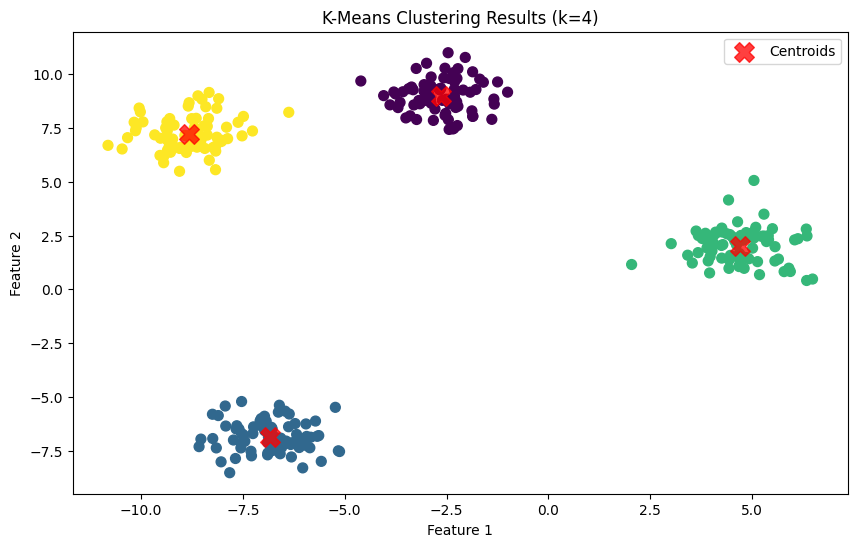

Final centroid coordinates (Feature 1, Feature 2):
  Cluster 0: (-2.64, 8.99)
  Cluster 1: (-6.84, -6.84)
  Cluster 2: (4.70, 2.03)
  Cluster 3: (-8.83, 7.22)


In [3]:
# 1. Fit K-Means with the chosen k=4. The 4-step algorithm from the lecture (Slide 6) runs internally:
#    Initialize -> Assign -> Update -> Repeat (until centroids stop moving).
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# 2. Each data point gets a cluster label (0, 1, 2, or 3) -- which centroid it ended up closest to
labels = kmeans.labels_

# 3. The final centroid coordinates -- the "typical member" of each cluster (Slide 11)
centers = kmeans.cluster_centers_

# 4. Plot points colored by their assigned cluster, with the centroids overlaid as red Xs
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title('K-Means Clustering Results (k=4)')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Print where each centroid landed -- in a customer-segmentation context (Slide 12), each of these
# would describe a distinct group: the average behavior pattern of that segment.
print("Final centroid coordinates (Feature 1, Feature 2):")
for i, c in enumerate(centers):
    print(f"  Cluster {i}: ({c[0]:.2f}, {c[1]:.2f})")

## Part 3: Principal Component Analysis (PCA)

**Concept:** PCA is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.

**Use Cases:**
*   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.
*   **Performance:** Speeding up model training by using fewer features.

**Problem:** We will use the Iris dataset, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset

**Your Task:** Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

Explained variance by component: [0.92461872 0.05306648]
Total variance explained by 2 components: 97.77%


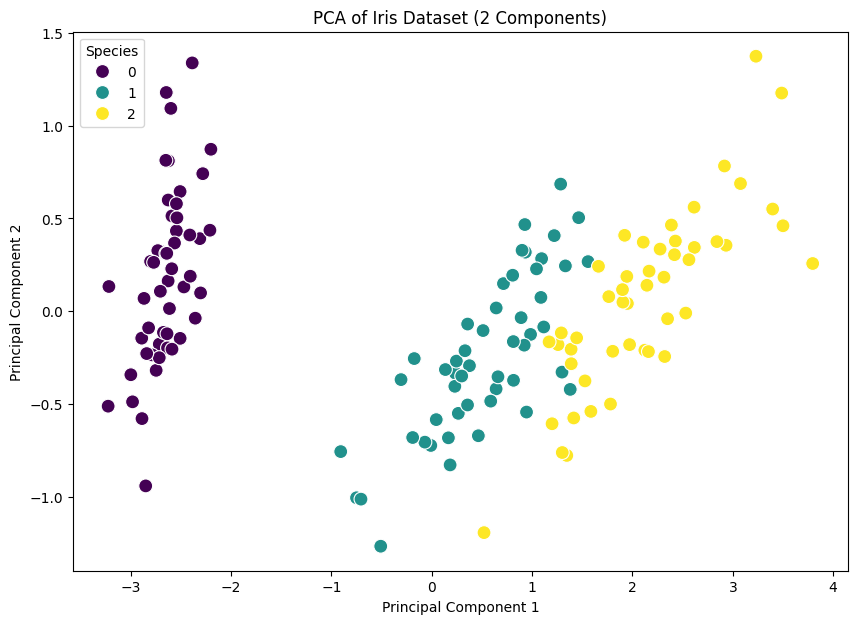

In [4]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns   # needed for sns.scatterplot below; not in the original imports

# Load the Iris data: 150 samples x 4 features (sepal length/width, petal length/width)
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Note: Slide 27 recommends standardizing features before PCA because PCA is
# "Sensitive to Scaling" (Slide 24) -- features with larger ranges would dominate the
# components. We're keeping the raw data here because all 4 Iris features are already
# measured on the same scale (cm), so scaling isn't critical. On a real-world dataset
# mixing dollars, ages, and counts, we would absolutely call StandardScaler first.

# 1. Build a PCA transformer that will keep the top 2 principal components.
# Conceptually: find the 2 directions in the 4D space along which the data varies most
# (the lecture's "best camera angles" -- Slide 18, 19).
pca = PCA(n_components=2)

# 2. Fit PCA (learn the principal directions) AND project the data onto those 2 components
X_pca = pca.fit_transform(X_iris)

# 3. Show how much variance each kept component captures
# These add up to a percentage representing how much of the original 4D structure
# survives the reduction to 2D.
print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# 4. Build a DataFrame for plotting -- nicer than juggling raw arrays
pca_df = pd.DataFrame(data=X_pca, columns=["Principal Component 1", "Principal Component 2"])
pca_df["Species"] = y_iris

# 5. Scatter plot in the new 2D PC space, colored by species.
# Note: PCA is unsupervised -- it never saw the species labels. If species separate
# cleanly along PC1/PC2 anyway, that proves the labels reflect REAL structure in the
# raw measurements, not just a label-driven artifact.
plt.figure(figsize=(10, 7))
sns.scatterplot(x="Principal Component 1", y="Principal Component 2",
                hue="Species", data=pca_df, palette='viridis', s=100)
plt.title('PCA of Iris Dataset (2 Components)')
plt.show()

## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

1.  **What is the fundamental difference between supervised and unsupervised learning?**
2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**
3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?**

---

### My Answers

**1. The fundamental difference between supervised and unsupervised learning:**

The defining difference is the presence (or absence) of **labels** in the training data. The lecture's analogy on Slide 3 captured it best for me:

- **Supervised learning** is like learning with a teacher who provides the correct answers. We give the algorithm both the inputs (X) and the right outputs (y), and it learns the mapping `X → y` so it can predict y for new inputs. Every model we built before this module — logistic regression on Titanic survival, decision trees on Iris species, polynomial regression on the sine wave — was supervised.

- **Unsupervised learning** is like exploring a new city without a map (Slide 3) — you don't have a guidebook telling you which streets matter; you discover the neighborhoods and landmarks on your own. The algorithm only gets the inputs (X) and has to find structure on its own, with no "correct answer" to check against. That's exactly what we did in this lab: K-Means *discovered* the four blobs without ever being told there were four, and PCA *discovered* the directions of maximum variance without ever being told what to look for.

**Why does this matter?** Labels are expensive. Labeling a million customer transactions as "fraud" or "not fraud" requires human investigators. Labeling medical images requires doctors. In contrast, unlabeled data is everywhere — every server log, every transaction stream, every photo on the internet. Unsupervised methods unlock the value in that vastly larger pool of unlabeled data. The two main techniques (Slide 2) are **clustering** (find natural groups) and **dimensionality reduction** (compress while preserving information), and we used one example of each in this lab.

**2. Why we don't just pick the largest possible k:**

Because **inertia is a trick question.** Inertia measures the sum of squared distances from each point to its nearest centroid. By definition, the more centroids you add, the closer every point is to *some* centroid, and the smaller the total distance becomes. In the extreme case, if you set `k = number of data points`, every point IS a centroid and inertia drops to exactly **zero**. That doesn't mean you found a great clustering — it means you found no clustering at all. You just memorized the data. (This is the same overfitting trap from Module 08, just in unsupervised disguise.)

What we actually want is **meaningful structure** — a small number of groups where each group is internally similar and clearly different from the others. The **elbow method** (Slide 8) gives us a principled way to find this point. We look at where adding another cluster stops giving us a *big* improvement and starts giving us only a *marginal* one. In this lab, the inertia drops dramatically from k=1 to k=4 (from ~19,800 down to ~360), then nearly flatlines from k=4 onward (the drop from k=4 to k=5 is only about 33). That sharp bend at k=4 is the elbow, and it correctly recovers the true structure (`make_blobs(centers=4)`).

Worth noting from Slide 8–9: the elbow method isn't the only tool. We can also use **domain knowledge** (the business already knows it has 3 customer tiers), **Silhouette Analysis** (a more rigorous score for cluster separation), or just **trial and error** with visual inspection. Often the right K isn't statistical at all; it's whatever number makes operational sense for the problem.

**3. What 95%+ explained variance from 2 components tells us about the Iris data:**

It tells us the original 4-dimensional Iris dataset is **not really 4-dimensional in any meaningful sense.** The four features (sepal length, sepal width, petal length, petal width) carry a lot of redundant information — the actual variation that distinguishes the flowers lives along just two underlying directions in feature space. Specifically in our run, **PC1 alone explained ~92.5%** of the variance and PC2 added another ~5.3%, totaling ~97.8%. Throwing away the other two components costs us only ~2% of the structure.

The lecture's **football-cloud analogy** (Slide 20) makes this concrete: imagine the 150 iris samples as a cloud of points in 4D space. PC1 is the longest axis of that football — the single direction along which the points are most spread out (and it turns out PC1 separates the species almost on its own). PC2 is the next-longest axis, perpendicular to PC1. Together they capture nearly all the shape; PC3 and PC4 are the football's much-thinner cross-sections, mostly noise.

**The practical implications are big:**
- **Visualization wins.** We can plot the 4D dataset honestly in 2D without misleading anyone, because we're showing 97.8% of the real structure.
- **The species are real, separable structure.** PCA is unsupervised — it never saw the labels — yet the species cluster into clearly distinct regions in PC space. That tells me the labels reflect actual measurable differences, not arbitrary categories.
- **Strong feature correlation.** If 92% of the variance lives along a single direction, the original 4 features must be heavily correlated. (Petal length and petal width almost certainly move together — bigger flowers have both bigger petals in length and width.) That correlation is exactly what dimensionality reduction is designed to exploit.
- **Curse of dimensionality avoided.** With only 2 effective dimensions, we sidestep the issues from Slide 17 (data sparsity, computational cost, overfitting risk in higher-dimensional learning).

## 🤔 Reflection

**What I learned:**

The biggest mental shift this module was letting go of the "answer key." Every previous module trained the model against ground truth and reported accuracy or precision against that truth. With unsupervised learning, **there is no answer key** — the algorithm is supposed to find structure that we ourselves don't know. That changes how you evaluate success: instead of "is the prediction right?" the question becomes "does the structure the algorithm found make sense?" Inertia, explained variance, silhouette scores, and visual inspection are all ways of asking that softer question.

The two specific techniques felt very different in flavor but solve complementary problems:
- **K-Means** answers "are there natural groups in this data, and what are they?" The lecture's **"K flags on a map"** framing (Slide 5) made the algorithm intuitive — plant flags, let everyone walk to the nearest one, move the flags to the center of their crowd, repeat until nobody moves.
- **PCA** answers "can I describe this data using fewer numbers without losing the important parts?" The **"best camera angle"** framing (Slide 18–19) clicked for me — PCA is finding the angles to photograph a 3D object that show the most detail in 2D.

**Challenges:**

The trickiest concept was understanding why we even *need* an elbow method. My first instinct was "surely the algorithm can figure out k itself." But the more I thought about it, the clearer it became that this is a fundamental tension in clustering: there's no objective definition of "correct number of clusters" — it depends on what you'll *do* with the clusters. A retailer might want 3 segments for marketing simplicity; a research scientist might want 12 for fine-grained patterns; the same dataset supports both. K-Means' biggest weakness (Slide 15: "Requires K Upfront") is actually a feature in disguise: it forces the analyst to decide what level of granularity they care about, instead of letting the algorithm pretend that's a purely mathematical question.

**Connections:**

This module connects to almost everything we've done:
- **Module 07 (model evaluation)**: explained variance is to PCA what accuracy is to a classifier — a single number summarizing how much of the underlying truth the model captures. The 95% threshold (Slide 21) is analogous to picking an accuracy target.
- **Module 08 (bias-variance)**: cranking k up to maximum is the unsupervised version of overfitting — zero training error / inertia, zero generalization value.
- **Module 09 (ensembles)**: feature importance from Random Forest and explained variance from PCA are doing related jobs — both are telling you which directions in feature space carry the signal. The methods differ but the goal (interpretability + dimensionality awareness) is the same.
- **Forward**: The **PCA + K-Means workflow** the lecture recommends on Slide 25 (apply PCA first to denoise and reduce, then cluster on the principal components) is something I want to try on a real high-dimensional dataset — it should give cleaner, faster, and more visualizable clusters than running K-Means directly on raw 50-feature data.

**Takeaways for future projects:**

1. **Always standardize features before PCA or K-Means** (Slide 27). Both algorithms are distance-based, so a feature measured in dollars (range: 0–100,000) will completely overwhelm a feature measured in years (range: 18–80) unless you scale them to comparable ranges first. The Iris dataset got away without it because all four features are already in cm; real-world data almost never is.
2. **Use `n_init=10` (or higher) on K-Means.** It's a one-line defense against the "Sensitive to Initialization" weakness from Slide 15. The cost is small; the protection against a bad random start is real.
3. **Plot the elbow AND look at the actual numbers.** The visual elbow can be ambiguous on real data. Looking at the first-difference table (how much inertia drops between consecutive k values) often makes the bend more obvious than the eye does.
4. **Match the algorithm to the cluster shape.** K-Means' "Assumes Spherical Clusters" weakness (Slide 15) means it'll misbehave on crescent-moon or ring-shaped data. For non-spherical or unknown-shape clusters, the lecture's recommended alternatives are **DBSCAN** (density-based, handles weird shapes and outliers) and **Hierarchical Clustering** (lets you pick K post-hoc by cutting the dendrogram).
5. **For visualization of nonlinear structure, reach for t-SNE or UMAP** (Slide 24), not PCA. PCA is linear — it can only find structure that lives along straight directions. Nonlinear methods can unfold curved manifolds that PCA flattens incorrectly.